In [2]:
import os
import glob
import h5py       
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["image.origin"] = "lower"  

In [3]:
DATA_DIR = r"C:\Work\College\DeepONets\wave_first"

PATTERN = "*.mat"

mat_files = sorted(glob.glob(os.path.join(DATA_DIR, PATTERN)))

file = mat_files[0]


In [4]:
with h5py.File(file, "r") as f:
    top_keys = list(f.keys())
    print(top_keys)
    
    for key in ["t_out", "x", "U_out"]:
        if key in f:
            dset = f[key]
            print(f"{key}: shape={dset.shape}, dtype={dset.dtype}")
        else:
            print(f"{key} not found at top level.")


['U_out', 't_out', 'x']
t_out: shape=(8276, 1), dtype=float64
x: shape=(5120, 1), dtype=float64
U_out: shape=(5120, 8276), dtype=[('real', '<f8'), ('imag', '<f8')]


In [5]:
def loader(filepath, t_key="t_out", x_key="x", U_key="U_out"):
    with h5py.File(filepath, "r") as f:
        t = np.array(f[t_key]).squeeze()
        x = np.array(f[x_key]).squeeze()
        U_raw = np.array(f[U_key])

        if U_raw.dtype.names is not None and 'real' in U_raw.dtype.names:
            U_complex = U_raw['real'] + 1j * U_raw['imag']
            U = np.abs(U_complex)**2
        else:
            U = np.abs(U_raw)**2

        T, X = np.meshgrid(t, x, indexing='ij')
        
        if U.shape != T.shape:
            U = U.T

        output = np.column_stack([T.ravel(), X.ravel(), U.ravel()])

    return output

In [6]:
output = loader("C:\Work\College\DeepONets\wave_first\Re_78315_case3_1of160.mat")


In [7]:
t = output[:, 0]
x = output[:, 1]
U_sq = output[:, 2]

mask = (t > 200) & (x > 150) & (x < 650)

t = t[mask]
x = x[mask]
U_sq = U_sq[mask]

print(t.shape)
print(x.shape)
print(U_sq.shape)

(21951138,)
(21951138,)
(21951138,)


In [8]:
# Load one recording and compute envelope magnitude |U|
print("\nLoaded example recording:")
print("  • t shape:", t.shape)
print("  • x shape:", x.shape)
print("  • U shape:", U_sq.shape, "dtype:", U_sq.dtype)

if t[0] > t[-1]:
    idx = np.argsort(t)
    t = t[idx]
    U = U_sq[idx, :]

# Envelope amplitude
A = np.abs(U_sq)

print("\nEnvelope |U|^2 statistics for this recording:")
print("  • shape:", A.shape)
print("  • min:", A.min())
print("  • max:", A.max())
print("  • mean:", A.mean())
print("  • std :", A.std())



Loaded example recording:
  • t shape: (21951138,)
  • x shape: (21951138,)
  • U shape: (21951138,) dtype: float64

Envelope |U|^2 statistics for this recording:
  • shape: (21951138,)
  • min: 7.35165480908569e-10
  • max: 0.0665647067048186
  • mean: 0.0029885927128468354
  • std : 0.0034396918653974815


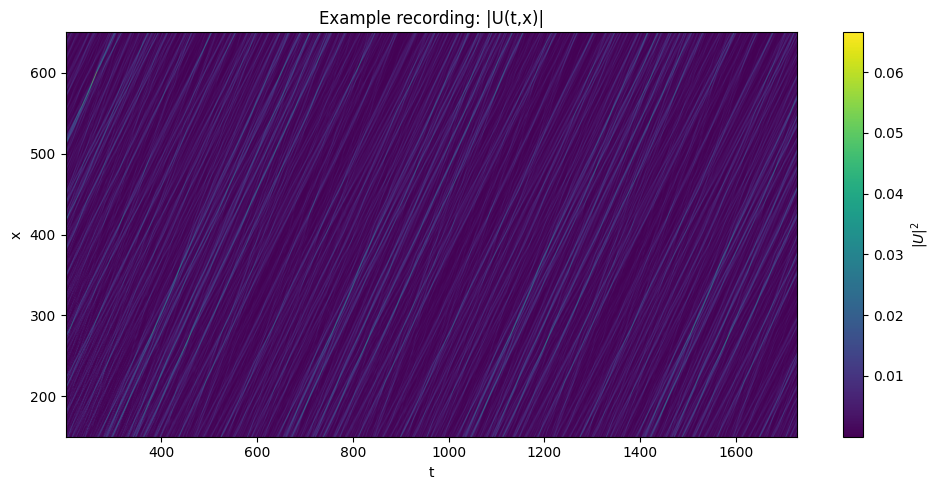

In [9]:
def plot_envelope_heatmap(t, x, A, title="|U(x,t)|^2"):
    # 1. Recover the grid axes from the 1D masked data
    t_vals = np.unique(t)
    x_vals = np.unique(x)
    
    Nt = len(t_vals)
    Nx = len(x_vals)
    
    # 2. Reshape 1D data back into a 2D Matrix (Time x Space)
    # We reshape to (Nt, Nx) then Transpose (.T) so Space is on the Y-axis
    try:
        A_grid = A.reshape(Nt, Nx).T
    except ValueError:
        print(f"Error: Cannot reshape data of length {len(A)} into grid {Nt}x{Nx}")
        return

    # 3. Plot
    plt.figure(figsize=(10, 5))
    
    plt.imshow(
        A_grid,
        origin="lower",
        aspect="auto",
        extent=[t_vals[0], t_vals[-1], x_vals[0], x_vals[-1]],
        cmap='viridis'
    )

    plt.colorbar(label=r"$|U|^2$")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Run it
plot_envelope_heatmap(t, x, A, title="Example recording: |U(t,x)|")

In [10]:
Nx = np.sum(t == t[0])
indices = np.arange(len(t))

t_idx = indices // Nx  
x_idx = indices % Nx  

mask_train_pattern = (t_idx % 2 != 0) & (x_idx % 2 != 0)
mask_test_pattern = (t_idx % 2 == 0) & (x_idx % 2 == 0)

t_train, x_train, U_train = t[mask_train_pattern], x[mask_train_pattern], U_sq[mask_train_pattern]
t_test,  x_test,  U_test  = t[mask_test_pattern],  x[mask_test_pattern],  U_sq[mask_test_pattern]

print(f"Train samples: {len(t_train)}")
print(f"Test samples:  {len(t_test)}")

Train samples: 5486138
Test samples:  5489431


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler_t = MinMaxScaler()
scaler_x = MinMaxScaler()
scaler_U = MinMaxScaler()

t_train_norm = scaler_t.fit_transform(t_train.reshape(-1, 1))
x_train_norm = scaler_x.fit_transform(x_train.reshape(-1, 1))
U_train_norm = scaler_U.fit_transform(U_train.reshape(-1, 1))

t_test_norm = scaler_t.transform(t_test.reshape(-1, 1))
x_test_norm = scaler_x.transform(x_test.reshape(-1, 1))
U_test_norm = scaler_U.transform(U_test.reshape(-1, 1))

t_train_norm = t_train_norm.flatten()
x_train_norm = x_train_norm.flatten()
U_train_norm = U_train_norm.flatten()

t_test_norm = t_test_norm.flatten()
x_test_norm = x_test_norm.flatten()
U_test_norm = U_test_norm.flatten()

print(f"Train U range: {U_train_norm.min():.4f} to {U_train_norm.max():.4f}")
print(f"Test U range:  {U_test_norm.min():.4f} to {U_test_norm.max():.4f}")

print(f"Train t range: {t_train_norm.min():.4f} to {t_train_norm.max():.4f}")
print(f"Test t range:  {t_test_norm.min():.4f} to {t_test_norm.max():.4f}")

Train U range: 0.0000 to 1.0000
Test U range:  -0.0000 to 0.9778
Train t range: 0.0000 to 1.0000
Test t range:  -0.0002 to 0.9998


In [12]:
Nx = 1666

total_points = U_train_norm.shape[0]
Nt = total_points // Nx


U_matrix = U_train_norm.reshape(Nt, Nx)
x_grid = x_train_norm[0:Nx]
t_grid = t_train_norm[0::Nx]

branch_inputs = U_matrix[:-1, :]
targets = U_matrix[1:, :]

target_times = t_grid[1:]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

branch_tensor = torch.tensor(branch_inputs, dtype=torch.float32).to(device)
target_tensor = torch.tensor(targets, dtype=torch.float32).to(device)

t_tensor = torch.tensor(target_times, dtype=torch.float32).reshape(-1, 1).to(device)

x_tensor = torch.tensor(x_grid, dtype=torch.float32).reshape(-1, 1).to(device)

dataset = TensorDataset(branch_tensor, t_tensor, target_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [13]:
import scipy.interpolate as interpolate

Nx_test_raw = 1667
Nt_test = len(U_test_norm) // Nx_test_raw

U_test_matrix_raw = U_test_norm.reshape(Nt_test, Nx_test_raw)
x_test_grid_raw = x_test_norm[:Nx_test_raw]
t_test_grid_unique = t_test_norm.reshape(Nt_test, Nx_test_raw)[:, 0]

Nx_train = 1666
x_train_grid = x_train_norm[:Nx_train] # The target grid

print(f"Resampling Test Data: {Nx_test_raw} points -> {Nx_train} points")

f_interp = interpolate.interp1d(x_test_grid_raw, U_test_matrix_raw, axis=1, kind='linear', fill_value="extrapolate")

U_test_matrix_fixed = f_interp(x_train_grid)

U_test_fixed_flat = U_test_matrix_fixed.flatten()

x_test_fixed_flat = np.tile(x_train_grid, Nt_test)

t_test_fixed_flat = np.repeat(t_test_grid_unique, Nx_train)

U_test_norm = U_test_fixed_flat
x_test_norm = x_test_fixed_flat
t_test_norm = t_test_fixed_flat

U_test_sequential = U_test_matrix_fixed  # Shape (Nt, 1666)
t_test_sequential = t_test_grid_unique   # Shape (Nt,)

print("Fix Complete.")
print(f"New U Shape: {U_test_norm.shape}")
print(f"New x Shape: {x_test_norm.shape}")

Resampling Test Data: 1667 points -> 1666 points
Fix Complete.
New U Shape: (5486138,)
New x Shape: (5486138,)


In [14]:
# --- 1. CONFIGURATION ---
Nx_model = 1666   # The dimension the model expects
Nt_test = len(t_test_norm) // Nx_model

print(f"Test Data Dimensions: {Nt_test} Time Steps x {Nx_model} Spatial Points")

# --- 2. RESHAPE TO MATRICES (Time, Space) ---
# We assume data is sorted: t0(all x), t1(all x)...
try:
    U_test_seq = U_test_norm.reshape(Nt_test, Nx_model)
    t_test_seq = t_test_norm.reshape(Nt_test, Nx_model)[:, 0] # Extract unique time per step
    x_test_grid = x_test_norm[:Nx_model] # Extract unique spatial grid
except ValueError as e:
    print("ERROR: Shape mismatch.")
    raise e

# Convert to Tensor for the model
# We treat the first 1666 x-points as the fixed grid for the Trunk
x_tensor_fixed = torch.tensor(x_test_grid, dtype=torch.float32).reshape(-1, 1).to(device)

Test Data Dimensions: 3293 Time Steps x 1666 Spatial Points


In [15]:
import torch
import torch.nn as nn
import numpy as np

# --- 1. LAYERS ---
class GCU(nn.Module):
    def forward(self, x):
        return x * torch.cos(x)

class TunableFourierMap(nn.Module):
    def __init__(self, input_dim, output_features, omega_0=5.0, sigma=10.0):
        super().__init__()
        
        # Initialization: A_i = omega_0 + sigma * |N(0, I)|
        noise_1 = torch.randn(output_features, input_dim)
        noise_2 = torch.randn(output_features, input_dim)
        
        w1_init = omega_0 + sigma * torch.abs(noise_1)
        w2_init = omega_0 + sigma * torch.abs(noise_2)
        
        self.W1 = nn.Parameter(w1_init)
        self.W2 = nn.Parameter(w2_init)

    def forward(self, x):
        proj_1 = 2 * torch.pi * (x @ self.W1.T)
        proj_2 = 2 * torch.pi * (x @ self.W2.T)
        return torch.cat([torch.sin(proj_1), torch.cos(proj_2)], dim=-1)

# --- 2. NETWORKS ---
class BranchNet(nn.Module):
    def __init__(self, p, q, hidden_size=256):
        super().__init__()
        
        # Branch Fourier Features (Lower freq defaults)
        self.phi = TunableFourierMap(p, 64, omega_0=0.5, sigma=1.0)
        
        mlp_input_dim = 2 * 64 
        
        self.hidden_layers = nn.Sequential(
            nn.Linear(mlp_input_dim, hidden_size),
            GCU(),
            nn.Linear(hidden_size, hidden_size),
            GCU()
        )
        
        # Bias=False for cleaner analytic solve (Least Squares)
        self.final_layer = nn.Linear(hidden_size, q, bias=False)

    def forward_hidden(self, x):
        features = self.phi(x)
        return self.hidden_layers(features)

    def forward(self, x):
        h = self.forward_hidden(x)
        return self.final_layer(h)

class TrunkNet(nn.Module):
    def __init__(self, q, input_dim=2, q_ff=64, hidden_size=256):
        super().__init__()
        
        # Trunk Fourier Features (Higher freq defaults)
        self.phi = TunableFourierMap(input_dim=input_dim, output_features=q_ff, sigma=10.0, omega_0=5.0)
        
        mlp_input_dim = 2 * q_ff
        
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, hidden_size),
            GCU(),
            nn.Linear(hidden_size, hidden_size),
            GCU(),
            nn.Linear(hidden_size, q)
        )

    def forward(self, coords):
        features = self.phi(coords) 
        return self.mlp(features)

class DeepONet(nn.Module):
    def __init__(self, branch_dim, trunk_dim, hidden_size, num_modes):
        super().__init__()
        
        self.branch = BranchNet(p=branch_dim, q=num_modes, hidden_size=hidden_size)
        self.trunk = TrunkNet(q=num_modes, input_dim=trunk_dim, q_ff=64, hidden_size=hidden_size)
        
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, u_input, t_batch, x_grid):
        batch_size = u_input.size(0)
        Nx = x_grid.size(0)

        # Branch Pass
        B = self.branch(u_input) 

        # Trunk Input Construction
        t_expanded = t_batch.view(batch_size, 1, 1).expand(batch_size, Nx, 1)
        x_expanded = x_grid.view(1, Nx, 1).expand(batch_size, Nx, 1)
        trunk_in = torch.cat([t_expanded, x_expanded], dim=-1)
        
        # Trunk Pass
        T = self.trunk(trunk_in)

        # Dot Product
        B_view = B.view(batch_size, 1, -1)
        output = torch.sum(B_view * T, dim=-1) + self.bias
        return output

In [16]:
test_branch_inputs = U_test_seq[:-1, :]
test_targets = U_test_seq[1:, :]
test_target_times = t_test_seq[1:]

test_branch_tensor = torch.tensor(test_branch_inputs, dtype=torch.float32).to(device)
test_target_tensor = torch.tensor(test_targets, dtype=torch.float32).to(device)
test_t_tensor = torch.tensor(test_target_times, dtype=torch.float32).reshape(-1, 1).to(device)

test_dataset = TensorDataset(test_branch_tensor, test_t_tensor, test_target_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
import torch.optim as optim
from tqdm import tqdm

# ===================== HYPERPARAMETERS =====================
LEARNING_RATE = 1e-4
EPOCHS = 400
MODES = 50
HIDDEN_SIZE = 256
BRANCH_DIM = 1666     # p
TRUNK_DIM = 2         # (t, x)
SUBSAMPLE_SPATIAL = 200  # Spatial points to subsample for lower-level solve
RIDGE_LAMBDA = 1e-6       # Regularization for least squares stability

# NEW: Blending parameter for W_final = mu * W_1 + (1-mu) * W_2
# mu = 0 -> pure lower-level solve (W_2)
# mu = 1 -> pure gradient descent (W_1)
MU = 0.7  # Try different values: 0.0, 0.1, 0.3, 0.5, 0.7

model = DeepONet(BRANCH_DIM, TRUNK_DIM, HIDDEN_SIZE, MODES).to(device)

# model.load_state_dict(torch.load("deeponet_trained_mu0.70.pth", map_location=device))


# Stage 1: Train ALL parameters (including final layer) via gradient descent
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

print(f"Model Initialized on {device}")
print("Starting Two-Stage Bilevel Training with Blending...")
print(f"  • Stage 1: Full DeepONet via Adam (LR={LEARNING_RATE}) -> W_1")
print(f"  • Stage 2: Lower-level solve via Vectorized SGD -> W_2")
print(f"  • Final:   W_final = {MU:.2f} * W_1 + {1-MU:.2f} * W_2")

loss_history = []
test_loss_history = []

pbar = tqdm(range(EPOCHS), desc="Training", unit="epoch")

for epoch in pbar:
    
    # =========================================================
    # STAGE 1: Train FULL DeepONet via Gradient Descent
    # =========================================================
    # This trains ALL parameters, including the final branch layer
    model.train()
    total_loss = 0
    
    for batch_idx, (u_prev, t_next, u_next) in enumerate(train_loader):
        u_prev = u_prev.to(device)
        t_next = t_next.to(device)
        u_next = u_next.to(device)
        
        optimizer.zero_grad()
        prediction = model(u_prev, t_next, x_tensor)
        loss = loss_fn(prediction, u_next)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Save W_1: the final layer weights after Stage 1
    W_1 = model.branch.final_layer.weight.data.clone()  # [Modes, Hidden]
    
    # =========================================================
    # STAGE 2: Lower-Level Solve via Vectorized SGD -> W_2
    # =========================================================
    # Solve min_W sum_i ||A_i W - y_i||^2 using SGD
    # Key insight: pred = (H @ W_matrix) @ T.transpose(1,2)
    
    model.eval()
    
    # Initialize W_matrix [Hidden, Modes] from current weights
    W_matrix = model.branch.final_layer.weight.data.T.clone()  # [Hidden, Modes]
    W_matrix = W_matrix.requires_grad_(True)
    
    W_optimizer = optim.Adam([W_matrix], lr=1e-2)
    
    # Fixed spatial subsample for this epoch
    spatial_indices = torch.randperm(BRANCH_DIM)[:SUBSAMPLE_SPATIAL].to(device)
    x_sub = x_tensor[spatial_indices]
    
    INNER_EPOCHS = 20  # Number of passes through data for lower-level solve
    
    for inner_epoch in range(INNER_EPOCHS):
        for u_prev, t_next, u_next in train_loader:
            u_prev = u_prev.to(device)
            t_next = t_next.to(device)
            u_next = u_next.to(device)
            
            batch_size = u_prev.size(0)
            
            # Get features (no grad needed for these)
            with torch.no_grad():
                H = model.branch.forward_hidden(u_prev)  # [Batch, Hidden]
                
                t_exp = t_next.view(batch_size, 1, 1).expand(batch_size, SUBSAMPLE_SPATIAL, 1)
                x_exp = x_sub.view(1, SUBSAMPLE_SPATIAL, 1).expand(batch_size, SUBSAMPLE_SPATIAL, 1)
                trunk_in = torch.cat([t_exp, x_exp], dim=-1)
                T = model.trunk(trunk_in)  # [Batch, Sub, Modes]
                
                u_target_sub = u_next[:, spatial_indices]  # [Batch, Sub]
            
            # ========== VECTORIZED FORWARD (No A_i formation!) ==========
            W_optimizer.zero_grad()
            
            HW = H @ W_matrix  # [Batch, Modes]
            pred = torch.bmm(HW.unsqueeze(1), T.transpose(1, 2)).squeeze(1)
            
            residual = pred - u_target_sub  # [Batch, Sub]
            
            # Loss: sum_i ||pred_i - y_i||^2 + ridge
            loss_W = (residual ** 2).sum() + RIDGE_LAMBDA * (W_matrix ** 2).sum()
            
            loss_W.backward()
            W_optimizer.step()
    
    # W_2: the result of lower-level solve
    W_2 = W_matrix.detach().T  # [Modes, Hidden]
    
    # =========================================================
    # BLEND: W_final = mu * W_1 + (1-mu) * W_2
    # =========================================================
    with torch.no_grad():
        W_final = MU * W_1 + (1 - MU) * W_2
        model.branch.final_layer.weight.copy_(W_final)
    
    # =========================================================
    # VALIDATION
    # =========================================================
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for u_test, t_test, u_target in test_loader:
            u_test = u_test.to(device)
            t_test = t_test.to(device)
            u_target = u_target.to(device)
            
            pred_test = model(u_test, t_test, x_tensor_fixed)
            test_loss = loss_fn(pred_test, u_target)
            total_test_loss += test_loss.item()
            
    avg_test_loss = total_test_loss / len(test_loader)
    test_loss_history.append(avg_test_loss) 
    
    # Update Progress Bar
    current_lr = optimizer.param_groups[0]['lr']
    pbar.set_postfix({
        "Train": f"{avg_loss:.2e}", 
        "Test": f"{avg_test_loss:.2e}", 
        "mu": f"{MU:.2f}"
    })

MODEL_PATH = f"deeponet_trained_mu{MU:.2f}.pth"
torch.save(model.state_dict(), MODEL_PATH)

print(f"\nTraining Complete. Model saved to {MODEL_PATH}")
print(f"Blending: W_final = {MU:.2f} * W_1 + {1-MU:.2f} * W_2")

# --- 4. Plot Loss ---
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Training Loss", alpha=0.7)
plt.plot(test_loss_history, label="Test Loss (Validation)", linewidth=2)
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title(f"Training vs Test Loss (mu={MU:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)   
plt.show()

Model Initialized on cuda
Starting Two-Stage Bilevel Training with Blending...
  • Stage 1: Full DeepONet via Adam (LR=0.0001) -> W_1
  • Stage 2: Lower-level solve via Vectorized SGD -> W_2
  • Final:   W_final = 0.70 * W_1 + 0.30 * W_2


Training:  67%|██████▋   | 267/400 [1:44:59<52:18, 23.60s/epoch, Train=1.48e-03, Test=4.52e-03, mu=0.70]     


KeyboardInterrupt: 

In [ ]:
def test_deeponet(model, U_matrix, t_vector, x_tensor_fixed, steps_to_rollout=100):
    model.eval()
    
    one_step_errors = []
    conservation_errors = []
    
    print(f"Checking One-Step accuracy over {len(U_matrix)-1} steps...")
    
    for i in range(len(U_matrix) - 1):
        # 1. Prepare Inputs
        u_current = torch.tensor(U_matrix[i], dtype=torch.float32).unsqueeze(0).to(device)
        t_next_val = t_vector[i+1]
        t_in = torch.tensor([[t_next_val]], dtype=torch.float32).to(device)
        
        # 2. Predict
        with torch.no_grad():
            pred = model(u_current, t_in, x_tensor_fixed).cpu().numpy().flatten()
        truth = U_matrix[i+1]
        
        # --- L1 ERROR CALCULATION ---
        # Formula: sum(|pred - truth|) / sum(|truth|)
        l1_err = np.linalg.norm(pred - truth, ord=1) / np.linalg.norm(truth, ord=1)
        one_step_errors.append(l1_err)
        
        # Conservation
        energy_pred = np.sum(pred)
        energy_true = np.sum(truth)
        conservation_errors.append(abs(energy_pred - energy_true)/energy_true)

    avg_1step_error = np.mean(one_step_errors)
    print(f"Average One-Step Rel. L1 Error: {avg_1step_error*100:.4f}%")
    print(f"Average Conservation Error:     {np.mean(conservation_errors)*100:.4f}%")

    # --- B. AUTOREGRESSIVE ROLLOUT ---
    print(f"\nRunning Autoregressive Rollout for {steps_to_rollout} steps...")
    
    current_u_tensor = torch.tensor(U_matrix[0], dtype=torch.float32).unsqueeze(0).to(device)
    rollout_preds = [U_matrix[0]]
    
    with torch.no_grad():
        for k in range(steps_to_rollout):
            if k + 1 >= len(t_vector): break
            next_t = t_vector[k+1]
            t_in = torch.tensor([[next_t]], dtype=torch.float32).to(device)
            pred_tensor = model(current_u_tensor, t_in, x_tensor_fixed)
            rollout_preds.append(pred_tensor.cpu().numpy().flatten())
            current_u_tensor = pred_tensor
            
    rollout_preds = np.array(rollout_preds)
    rollout_truth = U_matrix[:len(rollout_preds)]

    # --- L1 ERROR FOR ROLLOUT ---
    # axis=1 computes the norm across space for each time step individually
    rollout_errors = np.linalg.norm(rollout_preds - rollout_truth, ord=1, axis=1) / \
                     np.linalg.norm(rollout_truth, ord=1, axis=1)
    
    return rollout_preds, rollout_truth, rollout_errors, t_vector[:len(rollout_preds)]

# --- EXECUTE TEST ---
ROLLOUT_STEPS = 3292

pred_rollout, true_rollout, errors_rollout, t_rollout = test_deeponet(
    model, 
    U_test_seq, 
    t_test_seq, 
    x_tensor_fixed, 
    steps_to_rollout=ROLLOUT_STEPS
)



In [ ]:
# --- 3. VISUALIZATION ---

# Plot A: Error Accumulation over Time
plt.figure(figsize=(10, 4))
plt.plot(t_rollout, errors_rollout * 100, 'r-', linewidth=2)
plt.title(f"Error Accumulation over {ROLLOUT_STEPS} Steps")
plt.xlabel("Time ($t$)")
plt.ylabel("Relative L2 Error (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Plot B: Spatial Snapshot Comparison (Last Step of Rollout)
# Compares the final simulated frame vs truth
last_idx = -1 
plt.figure(figsize=(10, 5))
plt.plot(x_test_grid, true_rollout[last_idx], 'k-', linewidth=2, label="Ground Truth")
plt.plot(x_test_grid, pred_rollout[last_idx], 'r--', linewidth=2, label=f"Prediction (Step {ROLLOUT_STEPS})")
plt.title(f"Wave Shape after {ROLLOUT_STEPS} Time Steps ($t={t_rollout[last_idx]:.2f}$)")
plt.xlabel("Position ($x$)")
plt.legend()
plt.grid(True)
plt.show()

# Plot C: Spatiotemporal Heatmap (Optional but Recommended)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Truth
ax[0].imshow(true_rollout.T, aspect='auto', origin='lower', extent=[t_rollout[0], t_rollout[-1], x_test_grid[0], x_test_grid[-1]])
ax[0].set_title("Ground Truth Dynamics")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Position x")

# Prediction
im = ax[1].imshow(pred_rollout.T, aspect='auto', origin='lower', extent=[t_rollout[0], t_rollout[-1], x_test_grid[0], x_test_grid[-1]])
ax[1].set_title("DeepONet Rollout")
ax[1].set_xlabel("Time")

plt.colorbar(im, ax=ax, label="|U|^2")
plt.show()

In [ ]:
# ============================================================
# DFT ANALYSIS: True vs Predicted Field
# ============================================================
# Compare the 2D DFT of the true and predicted fields on the test grid.
# Analyze how the error in frequency domain evolves with frequency norm bound (delta).
# Check if top-q dominant frequencies are reproduced by the DeepONet.

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Compute 2D DFT of both fields ---
# true_rollout and pred_rollout have shape (Nt, Nx)
# DFT will be computed using np.fft.fft2

dft_true = np.fft.fft2(true_rollout)
dft_pred = np.fft.fft2(pred_rollout)

# Shift zero frequency to center for easier analysis
dft_true_shifted = np.fft.fftshift(dft_true)
dft_pred_shifted = np.fft.fftshift(dft_pred)

Nt, Nx = true_rollout.shape
print(f"Field shape: Nt={Nt}, Nx={Nx}")
print(f"DFT shape: {dft_true.shape}")

# --- 2. Build frequency grid ---
# Frequency indices for k_1 (time) and k_2 (space)
freq_t = np.fft.fftshift(np.fft.fftfreq(Nt))  # Normalized frequencies in [-0.5, 0.5)
freq_x = np.fft.fftshift(np.fft.fftfreq(Nx))

# Create meshgrid of frequency norms
K_t, K_x = np.meshgrid(freq_t, freq_x, indexing='ij')
freq_norm = np.sqrt(K_t**2 + K_x**2)

print(f"Max frequency norm: {freq_norm.max():.4f}")
print(f"Min frequency norm: {freq_norm.min():.4f}")

# --- 3. Compute error vs delta (frequency ball radius) ---
# For each delta, compute: ||DFT_true - DFT_pred||_2 restricted to ||k|| < delta

delta_values = np.linspace(0.01, 0.5, 50)
errors_vs_delta = []
relative_errors_vs_delta = []

for delta in delta_values:
    mask = freq_norm < delta
    
    # Flatten and extract values inside the ball
    diff = dft_true_shifted[mask] - dft_pred_shifted[mask]
    true_in_ball = dft_true_shifted[mask]
    
    # 2-norm of the gap
    error_2norm = np.linalg.norm(diff)
    true_2norm = np.linalg.norm(true_in_ball)
    
    errors_vs_delta.append(error_2norm)
    relative_errors_vs_delta.append(error_2norm / true_2norm if true_2norm > 0 else 0)

errors_vs_delta = np.array(errors_vs_delta)
relative_errors_vs_delta = np.array(relative_errors_vs_delta)

# --- 4. Plot: Relative DFT Error vs Frequency Ball Radius ---
plt.figure(figsize=(10, 6))
plt.plot(delta_values, relative_errors_vs_delta * 100, 'r-', linewidth=2)
plt.xlabel(r'$\delta$ (frequency ball radius)', fontsize=14)
plt.ylabel('Relative Error (%)', fontsize=14)
plt.title('Relative DFT Error vs Frequency Ball Radius', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TOP-Q FREQUENCY ANALYSIS
# ============================================================
# Check if the top-q most important frequencies (by magnitude in true field)
# are accurately reproduced by the DeepONet prediction.

# --- 5. Find top-q frequencies by magnitude in the true field ---
magnitude_true = np.abs(dft_true_shifted)
magnitude_pred = np.abs(dft_pred_shifted)

# Flatten and get indices sorted by magnitude (descending)
flat_magnitude_true = magnitude_true.flatten()
sorted_indices = np.argsort(flat_magnitude_true)[::-1]  # Descending order

# Convert flat indices to 2D indices
indices_2d = np.unravel_index(sorted_indices, magnitude_true.shape)

# --- 6. Analyze reproduction quality for top-q frequencies ---
q_values = [10, 25, 50, 100, 200, 500, 1000]
results = []

for q in q_values:
    # Get top-q indices
    top_q_idx_t = indices_2d[0][:q]
    top_q_idx_x = indices_2d[1][:q]
    
    # Extract DFT values at these frequencies
    dft_true_topq = dft_true_shifted[top_q_idx_t, top_q_idx_x]
    dft_pred_topq = dft_pred_shifted[top_q_idx_t, top_q_idx_x]
    
    # Compute metrics
    mag_true_topq = np.abs(dft_true_topq)
    mag_pred_topq = np.abs(dft_pred_topq)
    
    # Magnitude relative error
    mag_rel_error = np.linalg.norm(mag_true_topq - mag_pred_topq) / np.linalg.norm(mag_true_topq)
    
    # Complex relative error (captures both magnitude and phase)
    complex_rel_error = np.linalg.norm(dft_true_topq - dft_pred_topq) / np.linalg.norm(dft_true_topq)
    
    # Correlation of magnitudes
    correlation = np.corrcoef(mag_true_topq, mag_pred_topq)[0, 1]
    
    results.append({
        'q': q,
        'mag_rel_error': mag_rel_error * 100,
        'complex_rel_error': complex_rel_error * 100,
        'correlation': correlation
    })
    
    print(f"Top-{q:4d}: Magnitude Rel Error = {mag_rel_error*100:6.2f}%,  "
          f"Complex Rel Error = {complex_rel_error*100:6.2f}%,  "
          f"Correlation = {correlation:.4f}")

# --- 7. Visualize top-q analysis (4 separate full plots) ---

q_arr = [r['q'] for r in results]
mag_errs = [r['mag_rel_error'] for r in results]
cplx_errs = [r['complex_rel_error'] for r in results]
corrs = [r['correlation'] for r in results]

# PLOT 1: Error on Top-q Frequencies
plt.figure(figsize=(10, 6))
plt.plot(q_arr, mag_errs, 'bo-', linewidth=2, markersize=8, label='Magnitude Error')
plt.plot(q_arr, cplx_errs, 'ro-', linewidth=2, markersize=8, label='Complex Error')
plt.xlabel('q (number of top frequencies)', fontsize=14)
plt.ylabel('Relative Error (%)', fontsize=14)
plt.title('Error on Top-q Frequencies', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

# PLOT 2: Magnitude Correlation on Top-q Frequencies
plt.figure(figsize=(10, 6))
plt.plot(q_arr, corrs, 'go-', linewidth=2, markersize=8)
plt.xlabel('q (number of top frequencies)', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.title('Magnitude Correlation on Top-q Frequencies', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

# PLOT 3: Scatter of True vs Pred magnitudes for top-100
q_scatter = 100
top_idx_t = indices_2d[0][:q_scatter]
top_idx_x = indices_2d[1][:q_scatter]
mag_true_scatter = np.abs(dft_true_shifted[top_idx_t, top_idx_x])
mag_pred_scatter = np.abs(dft_pred_shifted[top_idx_t, top_idx_x])

plt.figure(figsize=(10, 8))
plt.scatter(mag_true_scatter, mag_pred_scatter, alpha=0.6, edgecolors='k', s=80)
max_val = max(mag_true_scatter.max(), mag_pred_scatter.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Agreement')
plt.xlabel('True DFT Magnitude', fontsize=14)
plt.ylabel('Predicted DFT Magnitude', fontsize=14)
plt.title(f'Top-{q_scatter} Frequencies: True vs Predicted Magnitude', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DETAILED DELTA ANALYSIS WITH CUMULATIVE ENERGY
# ============================================================
# Show what fraction of spectral energy is captured at each delta,
# and visualize the spatial distribution of dominant frequencies.

# --- 8. Cumulative spectral energy vs delta ---
total_energy_true = np.sum(np.abs(dft_true_shifted)**2)
total_energy_pred = np.sum(np.abs(dft_pred_shifted)**2)

delta_fine = np.linspace(0.005, 0.5, 100)
cumulative_energy_true = []
cumulative_energy_pred = []
energy_gap = []

for delta in delta_fine:
    mask = freq_norm < delta
    
    energy_true_in_ball = np.sum(np.abs(dft_true_shifted[mask])**2)
    energy_pred_in_ball = np.sum(np.abs(dft_pred_shifted[mask])**2)
    
    cumulative_energy_true.append(energy_true_in_ball / total_energy_true)
    cumulative_energy_pred.append(energy_pred_in_ball / total_energy_pred)
    
    # Normalized gap in energy within ball
    gap = np.abs(energy_true_in_ball - energy_pred_in_ball) / energy_true_in_ball if energy_true_in_ball > 0 else 0
    energy_gap.append(gap)

# --- 9. Visualize cumulative energy and gaps ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot A: Cumulative energy fraction
axes[0, 0].plot(delta_fine, cumulative_energy_true, 'b-', linewidth=2, label='True')
axes[0, 0].plot(delta_fine, cumulative_energy_pred, 'r--', linewidth=2, label='Predicted')
axes[0, 0].set_xlabel(r'$\delta$ (frequency ball radius)', fontsize=12)
axes[0, 0].set_ylabel('Fraction of Total Spectral Energy', fontsize=12)
axes[0, 0].set_title('Cumulative Spectral Energy vs Frequency Cutoff')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0.9, color='gray', linestyle=':', label='90% energy')
axes[0, 0].axhline(y=0.99, color='gray', linestyle='--', label='99% energy')

# Plot B: Energy gap
axes[0, 1].plot(delta_fine, np.array(energy_gap) * 100, 'purple', linewidth=2)
axes[0, 1].set_xlabel(r'$\delta$ (frequency ball radius)', fontsize=12)
axes[0, 1].set_ylabel('Relative Energy Gap (%)', fontsize=12)
axes[0, 1].set_title('Energy Gap Within Frequency Ball')
axes[0, 1].grid(True, alpha=0.3)

# Plot C: Visualize top-50 frequency locations
top_50_t = indices_2d[0][:50]
top_50_x = indices_2d[1][:50]
top_50_freq_t = freq_t[top_50_t]
top_50_freq_x = freq_x[top_50_x]
top_50_mag = magnitude_true[top_50_t, top_50_x]

# Normalize marker sizes
size_norm = (top_50_mag / top_50_mag.max()) * 300

axes[1, 0].scatter(top_50_freq_t, top_50_freq_x, s=size_norm, c=np.arange(50), 
                   cmap='viridis', alpha=0.7, edgecolors='k')
axes[1, 0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 0].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 0].set_xlabel(r'$k_t$ (temporal frequency)', fontsize=12)
axes[1, 0].set_ylabel(r'$k_x$ (spatial frequency)', fontsize=12)
axes[1, 0].set_title('Top-50 Dominant Frequencies\n(Size = Magnitude, Color = Rank)')
axes[1, 0].grid(True, alpha=0.3)

# Plot D: Log-magnitude spectrum comparison (2D)
fig2, ax2 = plt.subplots(1, 2, figsize=(14, 6))

log_mag_true = np.log10(magnitude_true + 1e-10)
log_mag_pred = np.log10(magnitude_pred + 1e-10)
vmin = min(log_mag_true.min(), log_mag_pred.min())
vmax = max(log_mag_true.max(), log_mag_pred.max())

im1 = ax2[0].imshow(log_mag_true, aspect='auto', origin='lower', 
                     extent=[freq_x.min(), freq_x.max(), freq_t.min(), freq_t.max()],
                     cmap='viridis', vmin=vmin, vmax=vmax)
ax2[0].set_xlabel(r'$k_x$ (spatial frequency)', fontsize=12)
ax2[0].set_ylabel(r'$k_t$ (temporal frequency)', fontsize=12)
ax2[0].set_title('Log |DFT| - True Field')
plt.colorbar(im1, ax=ax2[0])

im2 = ax2[1].imshow(log_mag_pred, aspect='auto', origin='lower',
                     extent=[freq_x.min(), freq_x.max(), freq_t.min(), freq_t.max()],
                     cmap='viridis', vmin=vmin, vmax=vmax)
ax2[1].set_xlabel(r'$k_x$ (spatial frequency)', fontsize=12)
ax2[1].set_ylabel(r'$k_t$ (temporal frequency)', fontsize=12)
ax2[1].set_title('Log |DFT| - Predicted Field')
plt.colorbar(im2, ax=ax2[1])

plt.tight_layout()
plt.show()

# Plot E: Error heatmap in frequency domain
fig3, ax3 = plt.subplots(figsize=(10, 6))
error_map = np.abs(dft_true_shifted - dft_pred_shifted)
log_error_map = np.log10(error_map + 1e-10)

im3 = ax3.imshow(log_error_map, aspect='auto', origin='lower',
                  extent=[freq_x.min(), freq_x.max(), freq_t.min(), freq_t.max()],
                  cmap='hot')
ax3.set_xlabel(r'$k_x$ (spatial frequency)', fontsize=12)
ax3.set_ylabel(r'$k_t$ (temporal frequency)', fontsize=12)
ax3.set_title('Log |DFT Error|: True - Predicted')
plt.colorbar(im3, ax=ax3, label='Log10 |Error|')
plt.tight_layout()
plt.show()

# --- 10. Summary Table ---
print("\n" + "="*70)
print("SUMMARY: DFT Analysis of DeepONet Prediction Quality")
print("="*70)

# Find delta where 90% and 99% of true energy is captured
delta_90 = delta_fine[np.searchsorted(cumulative_energy_true, 0.9)]
delta_99 = delta_fine[np.searchsorted(cumulative_energy_true, 0.99)]

print(f"\nTrue field: 90% energy at delta < {delta_90:.4f}, 99% at delta < {delta_99:.4f}")

# Error at these deltas
idx_90 = np.searchsorted(delta_values, delta_90)
idx_99 = np.searchsorted(delta_values, delta_99)
if idx_90 < len(relative_errors_vs_delta):
    print(f"Relative DFT error at delta={delta_90:.4f}: {relative_errors_vs_delta[idx_90]*100:.2f}%")
if idx_99 < len(relative_errors_vs_delta):
    print(f"Relative DFT error at delta={delta_99:.4f}: {relative_errors_vs_delta[idx_99]*100:.2f}%")

print(f"\nTop-10 frequency correlation:  {results[0]['correlation']:.4f}")
print(f"Top-100 frequency correlation: {results[3]['correlation']:.4f}")
print("="*70)